# 05 — Magnetometric (SQUID) haloscope

Synthesize a SQUID flux-noise floor, inject an axion line at the ADMX band, and score it with the Gaussian-PSD Loeb-Turner test.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from anomalymetric.magnetometric.spectrum import squid_band_grid, squid_reference_psd
from anomalymetric.magnetometric.score import squid_score
from anomalymetric.magnetometric.haloscope import ADMX, axion_mass_to_freq_hz
from anomalymetric.ingest.synthetic_psd import synthetic_squid_natural, synthetic_squid_with_exotic
from anomalymetric.units import bin_centers_eV, ev_to_hz

In [2]:
# Noise floor and an injected axion line at an ADMX-band mass.
bg = synthetic_squid_natural(seed=0)
base = synthetic_squid_natural(seed=1, noise=False)
m_a = float(ADMX.mass_grid_eV(4)[2])
sig = synthetic_squid_with_exotic(base, line_E_eV=m_a, line_amplitude=8.0, seed=2)
print('axion mass %.3g eV -> %.3e Hz' % (m_a, axion_mass_to_freq_hz(m_a)))

axion mass 3.28e-06 eV -> 7.937e+08 Hz


In [3]:
r_bg, r_sig = squid_score(bg), squid_score(sig)
print('noise : TS=%.2f score=%.2f best=%s' % (r_bg.test_statistic, r_bg.anomaly_score, r_bg.best_template))
print('axion : TS=%.2f score=%.2f best=%s' % (r_sig.test_statistic, r_sig.anomaly_score, r_sig.best_template))

noise : TS=2.66 score=0.26 best=axion.admx_1
axion : TS=10644.26 score=300.00 best=axion.admx_2


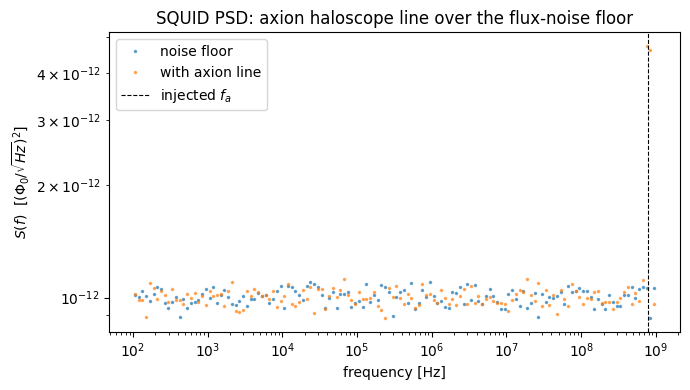

In [4]:
f = ev_to_hz(bin_centers_eV(sig.log_energy_edges_eV))
plt.figure(figsize=(7,4))
plt.loglog(f, bg.value, '.', ms=3, label='noise floor', alpha=0.6)
plt.loglog(f, sig.value, '.', ms=3, label='with axion line', alpha=0.6)
plt.axvline(axion_mass_to_freq_hz(m_a), color='k', ls='--', lw=0.8, label='injected $f_a$')
plt.xlabel('frequency [Hz]'); plt.ylabel(r'$S(f)$  [$(\Phi_0/\sqrt{Hz})^2$]')
plt.legend(); plt.title('SQUID PSD: axion haloscope line over the flux-noise floor')
plt.tight_layout()